<a href="https://colab.research.google.com/github/Tomer-P/ML_University_Studies/blob/main/assignment3/sgd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from skeleton_sgd import helper
import numpy as np
import matplotlib.pyplot as plt

train_data, train_labels, val_data, val_labels, test_data, test_labels = helper()
eta0_list = [10**-5, 10**-4, 10**-3, 10**-2, 10**-1, 1, 10, 100, 1000, 10000, 100000]

In [ ]:
def Prediction_Function(w, x):
  w = np.array(w).flatten()
  x = np.array(x).flatten()

  return np.dot(w, x)

In [ ]:
def Hinge_Loss_Function(predicted_value, y):
  return max(0, 1 - y * predicted_value)

In [ ]:
def Update_Function(w_old, step, C, y, x, score):
    if y * score < 1:
        return (1 - step) * w_old + step * C * y * x
    return (1 - step) * w_old

In [ ]:
def SGD_hinge(train_data, train_labels, val_data, val_labels, test_data, test_labels):
    acc_list = np.zeros(len(eta0_list))

    for j in range(len(eta0_list)):
        accuracies_list = []
        eta0 = eta0_list[j]

        for run in range(10):
            with np.errstate(over='ignore', invalid='ignore'):
                w = SGD_hinge_single(train_data, train_labels, eta0, C=1, T=1000)

            if not np.all(np.isfinite(w)):
                acc = 0
            else:
                acc = get_accuracy(w, val_data, val_labels)

            accuracies_list.append(acc)

        acc_list[j] = np.mean(accuracies_list)

    return acc_list

In [ ]:
def SGD_hinge_single(train_data, train_labels, eta0, C, T):
    w = np.zeros(train_data.shape[1])
    n = train_data.shape[0]

    for t in range(1, T + 1):
        i = np.random.randint(n)

        x = train_data[i]
        y = train_labels[i]

        etat = eta0 / t
        score = Prediction_Function(w, x)

        w = Update_Function(w, etat, C, y, x, score)

        if not np.all(np.isfinite(w)):
            return w

    return w

In [ ]:
def get_accuracy(w, val_data, val_labels):
  w = np.array(w).flatten()
  scores = np.dot(val_data, w)
  predictions = np.sign(scores)
  return np.mean(predictions.flatten() == val_labels.flatten())

In [ ]:
def plot_results(eta0_list, acc_list):
  plt.figure(figsize=(8, 5))

  plt.plot(eta0_list, acc_list, marker='o', linestyle='-', color='#FA76C1', markerfacecolor = '#FDC8E6', markeredgecolor = '#FCADDA')

  plt.xscale('log')

  plt.xlabel('Learning Rate (eta0)')
  plt.ylabel('Average Accuracy on Validation Set')
  plt.title('Performance vs. Learning Rate')
  plt.grid(True, which="both", ls="-", alpha=0.5)

  plt.show()

In [ ]:
C_list = [10**-5, 10**-4, 10**-3, 10**-2, 10**-1,
          1, 10, 100, 1000, 10000, 100000]

def find_best_C(train_data, train_labels,
                val_data, val_labels,
                best_eta0):

    acc_list = np.zeros(len(C_list))

    for j in range(len(C_list)):
        C = C_list[j]
        accuracies_list = []

        for run in range(10):

            with np.errstate(over='ignore', invalid='ignore'):
                w = SGD_hinge_single(
                    train_data,
                    train_labels,
                    eta0=best_eta0,
                    C=C,
                    T=1000
                )

            if not np.all(np.isfinite(w)):
                acc = 0
            else:
                acc = get_accuracy(w, val_data, val_labels)

            accuracies_list.append(acc)

        acc_list[j] = np.mean(accuracies_list)

    return acc_list

In [ ]:
def plot_C_results(C_list, acc_list):
    plt.figure(figsize=(8, 5))

    plt.plot(
        C_list,
        acc_list,
        marker='o',
        linestyle='-',
        color='#FA76C1',
        markerfacecolor='#FDC8E6',
        markeredgecolor='#FCADDA'
    )

    plt.xscale('log')

    plt.xlabel('C')
    plt.ylabel('Average Accuracy on Validation Set')
    plt.title('Performance vs. C')
    plt.grid(True, which="both", ls="-", alpha=0.5)

    plt.show()

In [ ]:
def train_best_classifier_and_show_image(train_data, train_labels, best_eta0, best_C):
    w = SGD_hinge_single(
        train_data,
        train_labels,
        eta0=best_eta0,
        C=best_C,
        T=20000
    )

    plt.figure(figsize=(5, 5))
    plt.imshow(np.reshape(w, (28, 28)), interpolation='nearest')
    plt.title("Learned weight vector w")
    plt.colorbar()
    plt.show()

    return w

In [ ]:
def main():
  acc_list = SGD_hinge(train_data, train_labels, val_data, val_labels, test_data, test_labels)
  plot_results(eta0_list, acc_list)

  best_eta0 = 1

  acc_list_C = find_best_C(
    train_data,
    train_labels,
    val_data,
    val_labels,
    best_eta0
  )

  plot_C_results(C_list, acc_list_C)


  best_C = 1e-4

  w_best = train_best_classifier_and_show_image(
    train_data,
    train_labels,
    best_eta0,
    best_C
  )

  test_acc = get_accuracy(w_best, test_data, test_labels)
  print(test_acc)

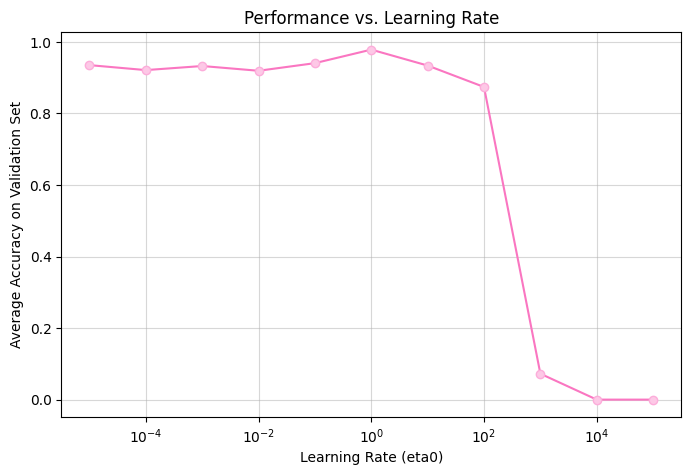

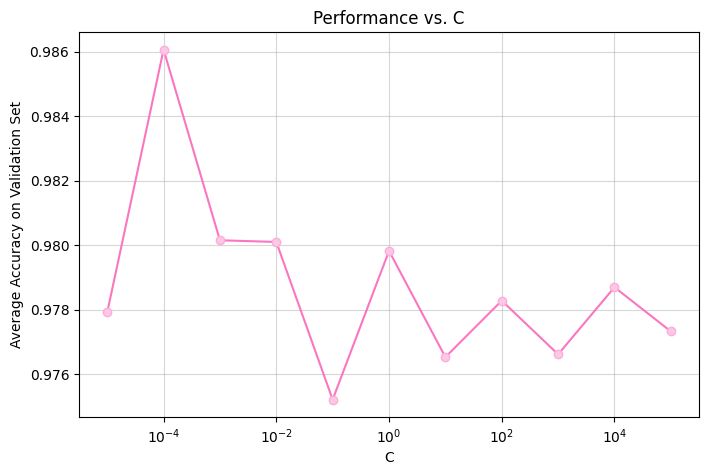

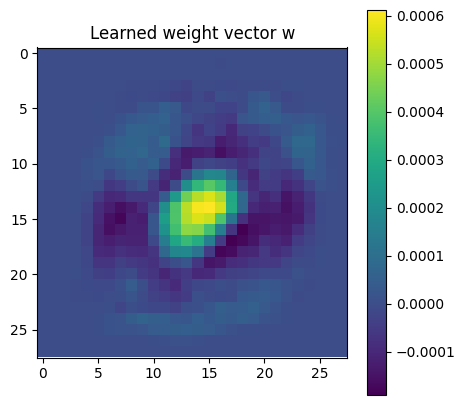

0.9923234390992836


In [ ]:
if __name__ == "__main__":
    main()